# 03-04 - The Ground Under the Field

The photographs of the class flight will become, among other things, a surface model, a grid of heights with the roofs and the tree crowns on it. To read one you need the other kind of height model, the terrain, the bare ground with everything removed, because the height of a thing is the surface minus the terrain. The United States Geological Survey publishes one at a metre through its 3D Elevation Program, built from New Jersey's statewide lidar, and this notebook is about reading it well before the drone adds the surface.

We open the window around Poe Field and read what it says about itself, including the two facts a height must carry that a position does not, its vertical datum and its date. We shade it by hand to see the relief, and watch the relief turn inside out when the light comes from the wrong side. We draw a section through the field with the buildings the flight will cross, and we get our first heights of buildings from their shadows on last summer's aerial photograph, using the sun's position solved from the shadows themselves rather than from a time stamp that turns out to be nominal. And we settle where zero is, since the drone's receiver and the 3DEP terrain model disagree about it by more than thirty metres.

Before you run anything, choose *File*, then *Save As*, and give the copy a name with `-mywork` in it, so that next week's pull never collides with your work.

In [1]:
import json
import math
import datetime as dt

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from shapely.geometry import Point
from matplotlib.colors import LightSource
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 72

## Three models of elevation

Three words are used for a grid of heights and they are not interchangeable. A digital elevation model, DEM, is any of them. A digital terrain model, DTM, is the bare ground, with buildings and vegetation removed. A digital surface model, DSM, is the top of everything, the roofs and the crowns. Matching photographs of a town produces a surface, since the camera sees roofs and not the ground under them, and lidar produces both, since a laser pulse returns first from the crown and last from the ground beneath it. New Jersey's lidar was flown once and published as bare earth only, so the federal 3D Elevation Program's model is what exists for this campus, and that is the file we open. We call it the 3DEP terrain model from here on, and so does every notebook after this one:

In [2]:
src = rasterio.open("data/dem_3dep_1m_site.tif")
print(src.crs, "|", src.width, "by", src.height, "cells of", src.res[0], src.crs.linear_units, "|", src.dtypes[0], "| nodata", src.nodata)
for key, value in src.tags().items():
    if key != "AREA_OR_POINT":
        print(f"{key:10} {value}")
z = src.read(1)
transform = src.transform
extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)

site = gpd.read_file("data/site.gpkg", layer="site").to_crs(src.crs)
inside = ~geometry_mask([site.geometry.iloc[0]], out_shape=z.shape, transform=transform)
reference = json.load(open("data/ground_truth.json"))["p03"]
print()
print(f"the window runs from {z.min():.1f} to {z.max():.1f} m above NAVD88")
print(f"the field's ground is {np.median(z[inside]):.2f} m, from {z[inside].min():.2f} to {z[inside].max():.2f} m, {z[inside].max() - z[inside].min():.2f} m of relief"
      f"   reference {reference['terrain']['site_ground_m']} m, {reference['terrain']['relief_over_site_m']} m of relief")

EPSG:26918 | 800 by 800 cells of 1.0 metre | float32 | nodata None
licence    Public domain, US federal government
note       bare earth terrain model; no surface model with buildings and trees is published for New Jersey
retrieved  2026-09-14
source     USGS 3DEP Elevation ImageServer, exportImage on a UTM 18N grid, four quadrants
units      metres above NAVD88
vintage    the service does not state the acquisition date of the lidar behind this surface
window     800 m around the site centroid, cut from the campus window of 15_fetch_lidar.py

the window runs from 15.8 to 65.5 m above NAVD88
the field's ground is 41.88 m, from 40.28 to 43.03 m, 2.76 m of relief   reference 41.88 m, 2.76 m of relief


An 800 m window of one metre cells in NAD 83's UTM zone 18 north, EPSG:26918, the system 03-01 met, with `float32` heights and no nodata value, which is why the smallest number in the window is a real height and not a sentinel. The tags answer the two questions a height must answer. The unit is metres above NAVD88, the North American Vertical Datum of 1988, which is the surface the United States calls sea level for mapping; a height without its vertical datum is as incomplete as a coordinate without its horizontal one. And the date is not given. The service says the file is a bare earth model and says where it comes from, but not when the aircraft flew, and the pipeline wrote that absence into the tags so that nobody mistakes it for a fact. The NJ Office of GIS lists the years of its own lidar, which is where you would look, and any of them predates the buildings finished since.

The numbers are what a campus on a low ridge above a lake should give. The window spans fifty metres of height, from the lake shore in the south to the top of the ridge, and the field itself sits at about 42 m with under three metres of relief across it, which is what a playing field is for.

## A hillshade by hand

A grid of heights is hard to read as numbers and easy to read as light. A hillshade puts an imaginary sun at a chosen direction and elevation and colours each cell by how squarely it faces the sun, which is a calculation from the slope and the aspect of the cell, and both of those come from the differences between neighbouring heights. Here it is in a dozen lines, then the same thing from matplotlib in one:

the hand made shade and matplotlib's agree with a correlation of 0.997


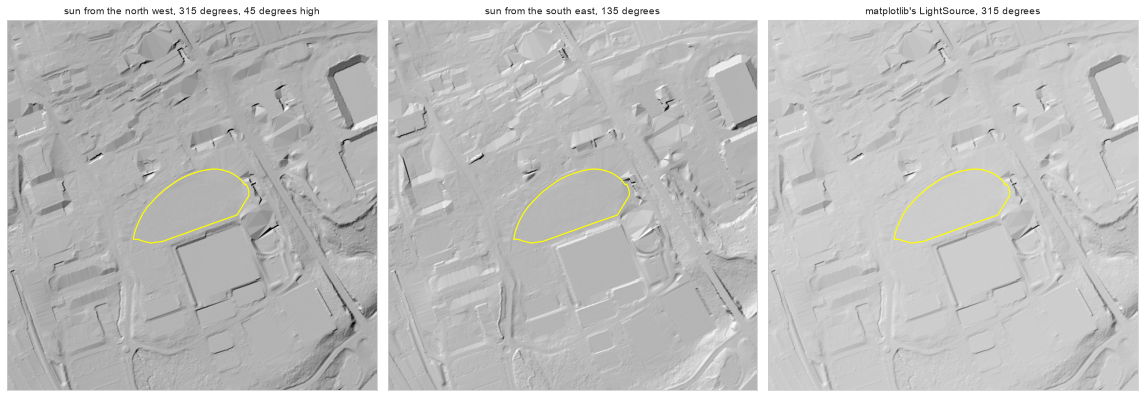

In [3]:
def hillshade(z, azimuth_deg, altitude_deg, cell=1.0):
    '''Illumination of each cell by a sun at the given azimuth (clockwise from north) and altitude.'''
    dz_row, dz_col = np.gradient(z, cell)          # change per row (downward, i.e. southward) and per column (eastward)
    dz_east, dz_north = dz_col, -dz_row             # rows count south, northings count north
    slope = np.arctan(np.hypot(dz_east, dz_north))
    aspect = np.arctan2(-dz_east, -dz_north)        # the downhill direction, clockwise from north
    az, alt = np.radians(azimuth_deg), np.radians(altitude_deg)
    shade = np.sin(alt) * np.cos(slope) + np.cos(alt) * np.sin(slope) * np.cos(az - aspect)
    return np.clip(shade, 0, 1)

by_hand = hillshade(z, 315, 45)
from_the_wrong_side = hillshade(z, 135, 45)
by_matplotlib = LightSource(azdeg=315, altdeg=45).hillshade(z, vert_exag=1, dx=1, dy=1)
print(f"the hand made shade and matplotlib's agree with a correlation of {np.corrcoef(by_hand.ravel(), by_matplotlib.ravel())[0, 1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, (title, shade) in zip(axes, (("sun from the north west, 315 degrees, 45 degrees high", by_hand),
                                     ("sun from the south east, 135 degrees", from_the_wrong_side),
                                     ("matplotlib's LightSource, 315 degrees", by_matplotlib))):
    ax.imshow(shade, cmap="gray", extent=extent, vmin=0, vmax=1)
    site.boundary.plot(ax=ax, color="yellow", linewidth=1.2)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()

With the sun in the north west, where every mapmaker puts it, the ridge reads as a ridge, the slope down to the lake as a slope, and the field as the flat shelf it is. Move the sun to the south east and the same numbers read inside out: the valleys look like ridges and the ridges like valleys. Nothing changed in the data. The eye assumes light from above and to the left, and a shaded relief lit from below tricks it every time, which is why the convention exists. The third panel is matplotlib doing the same arithmetic, and the correlation printed under the figure says the dozen lines got it right.

Look also at what a bare earth model shows and hides. The buildings are gone as heights, but you can still see where they stood. Under each footprint the ground was interpolated across, and where the campus is terraced the patch sits a metre above or below its surroundings with a sharp edge, so the shading draws faint blocks where the roofs were. Those are the scars of removal, not roofs, and the terraces, banks and paths around them are real. The surface model from Wednesday's flight will show the opposite, roofs and crowns and no ground under them, and 03-07 puts the two together.

## A section through the field

A section is a line across the map with the heights along it drawn as a profile, and it makes relief legible in a way no map does. The kit carries the line the lecture chose, the one through the centre of the field that crosses the most buildings, so that the profile shows what the flight will pass over:

In [4]:
section = gpd.read_file("data/site.gpkg", layer="section").to_crs(src.crs)
line = section.geometry.iloc[0]
distances = np.arange(0, line.length, 1.0)
points = [line.interpolate(d) for d in distances]
profile = np.array([v[0] for v in src.sample([(p.x, p.y) for p in points])])

field = site.geometry.iloc[0]
on_field = np.array([field.contains(p) for p in points])
field_ground = np.median(profile[on_field])
flight_line = field_ground + reference["camera"]["altitude_m"]

buildings = gpd.read_file("data/site.gpkg", layer="buildings_site").to_crs(src.crs)
crossed = buildings[buildings.intersects(line)].copy()
LABEL_MIN_M = 10                                          # a building clipped by a corner is crossed but not worth a label
boxes = []
for _, b in crossed.iterrows():
    part = b.geometry.intersection(line)
    if part.geom_type != "LineString":
        part = max(part.geoms, key=lambda g: g.length)    # a building the section leaves and re-enters; keep the longest crossing
    d0, d1 = sorted(line.project(Point(c)) for c in (part.coords[0], part.coords[-1]))
    if d1 - d0 >= LABEL_MIN_M:
        boxes.append((d0, d1, np.median(profile[int(d0):int(d1) + 1]), b["name"] if isinstance(b["name"], str) else "unnamed"))

print(f"a {line.length:.0f} m section at azimuth {int(section['azimuth_deg'].iloc[0])} degrees, ground {profile.min():.1f} to {profile.max():.1f} m above NAVD88")
print(f"it crosses {len(crossed)} buildings, of which {len(boxes)} are crossed for more than {LABEL_MIN_M} m and are labelled in the figure")
print(f"the field's ground is {field_ground:.1f} m and the flight line {flight_line:.1f} m above NAVD88, which happens to equal the 400 foot ceiling in metres and is a different thing")
print(f"the plan's pixel at {reference['camera']['altitude_m']:.0f} m above the field is {reference['camera']['gsd_cm'][str(int(reference['camera']['altitude_m']))]} cm")

a 500 m section at azimuth 0 degrees, ground 37.7 to 46.1 m above NAVD88
it crosses 8 buildings, of which 8 are crossed for more than 10 m and are labelled in the figure
the field's ground is 41.9 m and the flight line 121.9 m above NAVD88, which happens to equal the 400 foot ceiling in metres and is a different thing
the plan's pixel at 80 m above the field is 2.86 cm


Half a kilometre of ground, and the numbers before the picture. Now the picture, with the field shaded, the buildings the section crosses as dashed boxes and the flight line named in the caption:

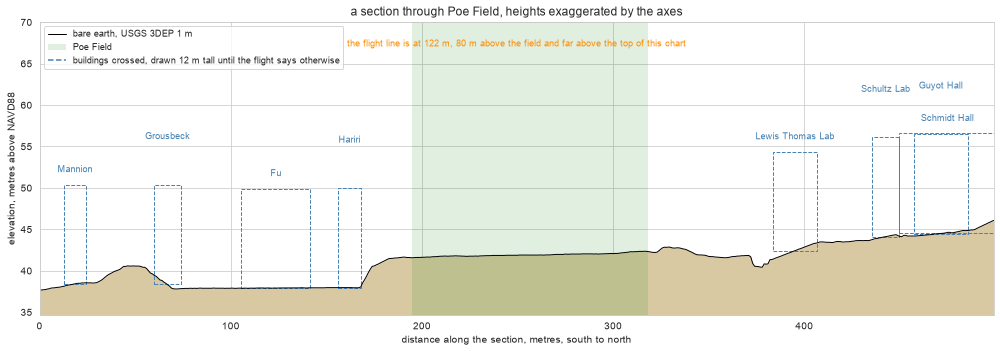

In [5]:
short = {"Eric and Wendy Schmidt Hall": "Schmidt Hall", "Lewis Thomas Laboratory": "Lewis Thomas Lab", "Carl Icahn Laboratory": "Icahn Lab", "Schultz Laboratory": "Schultz Lab"}
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(distances, profile.min() - 5, profile, color="#d9c9a3", linewidth=0)
ax.plot(distances, profile, color="black", linewidth=1, label="bare earth, USGS 3DEP 1 m")
ax.fill_between(distances, profile.min() - 5, profile.max() + 30, where=on_field, color="green", alpha=0.12, linewidth=0, label="Poe Field")
for k, (d0, d1, base, name) in enumerate(sorted(boxes)):
    ax.add_patch(plt.Rectangle((d0, base), d1 - d0, 12, facecolor="none", edgecolor="steelblue", linewidth=1, linestyle="--"))
    ax.annotate(short.get(name, name), ((d0 + d1) / 2, base + 13.5 + 4 * (k % 2)), ha="center", fontsize=9, color="steelblue")
ax.plot([], [], color="steelblue", linestyle="--", label="buildings crossed, drawn 12 m tall until the flight says otherwise")
ax.annotate(f"the flight line is at {flight_line:.0f} m, {reference['camera']['altitude_m']:.0f} m above the field and far above the top of this chart",
            (distances[-1] / 2, profile.max() + 21), ha="center", fontsize=9, color="darkorange")
ax.set_xlim(0, distances[-1]); ax.set_ylim(profile.min() - 3, profile.max() + 24)
ax.set_xlabel("distance along the section, metres, south to north"); ax.set_ylabel("elevation, metres above NAVD88")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("a section through Poe Field, heights exaggerated by the axes", fontsize=12)
fig.tight_layout()

Half a kilometre of ground from south to north, low at the southern end where the dormitories stand, the field as a flat shelf near 42 m in the middle, and a rise of a few metres toward the laboratories at the northern end, with the buildings the section crosses drawn as dashed boxes. The boxes are twelve metres tall for now, which is a guess the data does not support yet; 03-07 replaces the guess with the surface model's own heights. The flight line is eighty metres above the field, far off the top of this chart, and the plan of 03-03 keeps the aircraft at that height above the take-off point rather than above the ground beneath it. So over the higher ground to the north the aircraft is a few metres closer to what it photographs, and the pixels there come out a little smaller than the plan's, which the last line printed.

Read the axes before the shape. The horizontal axis runs five hundred metres and the vertical one a few tens, so the slopes you see are many times steeper than the ground; a section without its exaggeration stated is a lie by proportion.

## Heights from shadows

The bare earth has no buildings on it, but the aerial photograph of 2022 does, and every building casts a shadow whose length is its height times the cotangent of the sun's elevation. So a photograph and a clock give a height. The catch is the clock. The catalogue stamps the 2022 flight at 16:00 UTC, which is noon, and at noon in July the sun stands 68 degrees high. The shadows in the picture say otherwise. The pipeline measured the direction in which the shadows of the eight largest buildings near the field agree, and then asked at what time of that day the sun stood opposite it:

In [6]:
def sun_position(when_utc, lat, lon):
    '''Solar elevation and azimuth in degrees, azimuth clockwise from north, the NOAA solar calculator's algorithm; longitude positive east.'''
    jd = when_utc.toordinal() + 1721424.5 + (when_utc.hour + when_utc.minute / 60 + when_utc.second / 3600) / 24
    T = (jd - 2451545.0) / 36525
    L0 = (280.46646 + T * (36000.76983 + 0.0003032 * T)) % 360
    M = math.radians(357.52911 + T * (35999.05029 - 0.0001537 * T))
    C = (1.914602 - T * (0.004817 + 0.000014 * T)) * math.sin(M) + (0.019993 - 0.000101 * T) * math.sin(2 * M) + 0.000289 * math.sin(3 * M)
    omega = math.radians(125.04 - 1934.136 * T)
    app_long = math.radians(L0 + C - 0.00569 - 0.00478 * math.sin(omega))
    eps = math.radians(23.439291 - 0.0130042 * T + 0.00256 * math.cos(omega))
    decl = math.asin(math.sin(eps) * math.sin(app_long))
    y = math.tan(eps / 2) ** 2
    L0r = math.radians(L0)
    e = 0.016708634 - T * (0.000042037 + 0.0000001267 * T)
    eot = 4 * math.degrees(y * math.sin(2 * L0r) - 2 * e * math.sin(M) + 4 * e * y * math.sin(M) * math.cos(2 * L0r)
                           - 0.5 * y * y * math.sin(4 * L0r) - 1.25 * e * e * math.sin(2 * M))
    minutes = when_utc.hour * 60 + when_utc.minute + when_utc.second / 60
    tst = (minutes + eot + 4 * lon) % 1440
    ha_deg = tst / 4 - 180 if tst / 4 >= 0 else tst / 4 + 180
    ha, latr = math.radians(ha_deg), math.radians(lat)
    zen = math.acos(math.sin(latr) * math.sin(decl) + math.cos(latr) * math.cos(decl) * math.cos(ha))
    a = math.degrees(math.acos(((math.sin(latr) * math.cos(zen)) - math.sin(decl)) / (math.cos(latr) * math.sin(zen))))
    return 90 - math.degrees(zen), (a + 180) % 360 if ha_deg > 0 else (540 - a) % 360

lon, lat = reference["site"]["centre_lonlat"]
shadows = reference["shadows"]
stamped = dt.datetime.fromisoformat(shadows["datetime_nominal"].replace("Z", "+00:00")).replace(tzinfo=None)
solved = stamped.replace(hour=int(shadows["solved_time_utc"][:2]), minute=int(shadows["solved_time_utc"][3:]))
for label, when in (("the time stamp says", stamped), ("the shadows say", solved)):
    elev, az = sun_position(when, lat, lon)
    print(f"{label:20} {when:%Y-%m-%d %H:%M} UTC: sun {elev:.1f} degrees high at azimuth {az:.0f}, shadows toward {(az + 180) % 360:.0f}")
print(f"reference: shadows toward {shadows['shadow_azimuth_deg']} degrees, sun {shadows['sun_elevation_deg']} degrees high at {shadows['solved_time_utc']} UTC")

the time stamp says  2022-07-04 16:00 UTC: sun 68.0 degrees high at azimuth 138, shadows toward 318
the shadows say      2022-07-04 19:44 UTC: sun 52.0 degrees high at azimuth 255, shadows toward 75
reference: shadows toward 75 degrees, sun 52.0 degrees high at 19:44 UTC


The shadows in the 2022 picture point a little north of east, so the sun stood in the west south west, and on the fourth of July that is late afternoon, not noon. The stamp is the day, not the hour, and the sun it implies is sixteen degrees too high. Had we trusted it, every height from a shadow would have come out roughly twice too large. The lecture's eight elements of image interpretation included shadow for exactly this reason: it carries the height of things and the hour of the picture, and a photograph does not lie about its shadows.

Now one building. Guyot Hall stands north of the field, and we measure its shadow along the solved direction: walk from the centre of the footprint to its edge, then onward along the shadow, sampling the brightness of the photograph every thirty centimetres until the ground turns light again, and do it on several parallel rays so that a tree or a doorway does not decide the answer alone:

In [7]:
naip = rasterio.open("data/naip_2022_site.tif")
bright = naip.read([1, 2, 3]).astype("float32").mean(axis=0)
dark_level = (np.percentile(bright, 5) + np.percentile(bright, 50)) / 2   # halfway between the picture's darkest and its middle
guyot = buildings[buildings["name"] == "Guyot Hall"].geometry.iloc[0]
theta = math.radians(shadows["shadow_azimuth_deg"])
dx, dy = math.sin(theta), math.cos(theta)                 # one step of the walk, in the shadow's direction
step = 0.3                                                # how far apart we sample the photograph, in metres
WALK_MAX_M = 200                                          # far enough to leave any footprint
SHADOW_MAX_M = 60                                         # and far enough to cross any shadow on this campus
START_WITHIN_M = 3                                        # the shadow has to begin close to the wall, or it is somebody else's
GAP_SAMPLES = 2                                           # a bright doorstep or a car may interrupt it this much

def shadow_length(building, offset):
    '''The dark run beyond the footprint's edge along the shadow azimuth, on a ray offset sideways from the centroid,
    in metres. Returns None when the ray starts outside the building or finds no shadow at the wall.'''
    c = building.centroid
    px, py = c.x + offset * math.cos(theta), c.y - offset * math.sin(theta)
    if not building.contains(Point(px, py)):
        return None
    edge = next((d for d in np.arange(0, WALK_MAX_M, step) if not building.contains(Point(px + dx * d, py + dy * d))), None)
    samples = np.array([v[:3].mean() for v in naip.sample([(px + dx * (edge + d), py + dy * (edge + d)) for d in np.arange(0, SHADOW_MAX_M, step)])])
    dark = samples < dark_level
    starts = np.flatnonzero(dark[: int(START_WITHIN_M / step)])
    if not starts.size:
        return None
    i, gap = int(starts[0]), 0
    while i < len(dark) and gap <= GAP_SAMPLES:
        gap = 0 if dark[i] else gap + 1
        i += 1
    return (i - gap - int(starts[0])) * step              # from the first dark sample to the last, without the bright tail

rays = range(-15, 16, 5)                                  # five metres apart, across the shadow, so one doorway cannot decide
lengths = []
for offset in rays:
    found = shadow_length(guyot, offset)
    if found is not None:
        lengths.append(found)
shadow_m = float(np.median(lengths))
elev = shadows["sun_elevation_deg"]
height = shadow_m * math.tan(math.radians(elev))
ref = shadows["buildings"][0]
print(f"the dark level is a brightness of {dark_level:.0f}   reference {shadows['dark_level']}")
print(f"Guyot Hall: {len(lengths)} of {len(rays)} rays found a shadow, lengths {sorted(round(L, 1) for L in lengths)} m, median {shadow_m:.1f} m")
print(f"height = {shadow_m:.1f} m x tan({elev:.1f} degrees) = {height:.1f} m   reference shadow {ref['shadow_m']} m, height {ref['height_m']} m")
print(f"trusting the time stamp instead: {shadow_m * math.tan(math.radians(sun_position(stamped, lat, lon)[0])):.1f} m")

the dark level is a brightness of 85   reference 85.3
Guyot Hall: 5 of 7 rays found a shadow, lengths [0.3, 7.5, 11.1, 11.7, 11.7] m, median 11.1 m
height = 11.1 m x tan(52.0 degrees) = 14.2 m   reference shadow 11.1 m, height 14.2 m
trusting the time stamp instead: 27.5 m


Eleven metres of shadow, and read the list of lengths before the median. Two of the seven rays found no shadow at the wall at all, because they started outside the wing, and two of the five that did were cut short where the walk ran into a doorway or another part of the building. The median ignores both kinds of failure, which is why it is the median and not the mean. A height of fourteen metres follows for the wing of Guyot Hall the rays crossed, which is what a three storey stone building of 1909 should measure. With the stamped noon sun it would have come out at twenty seven. Wednesday's surface model will give this roof a height of its own, and 03-07 puts the two side by side.

Here is what the measurement looked like, the rays on the photograph and the brightness along the middle one:

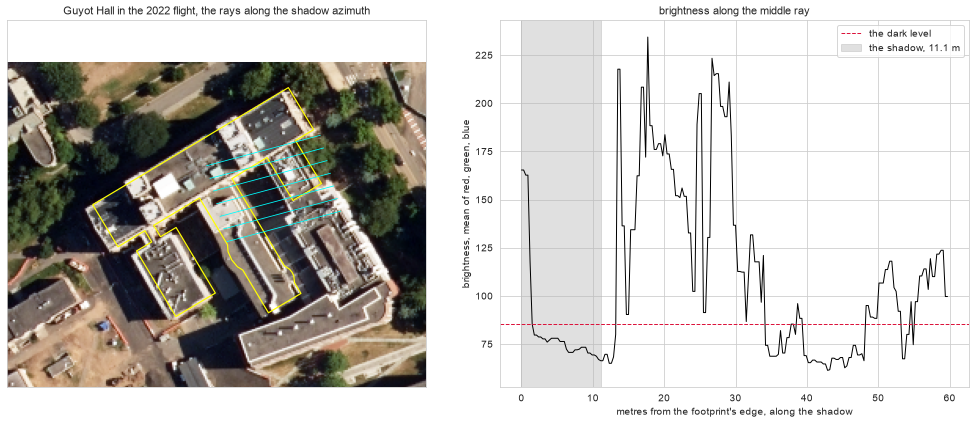

In [8]:
c = guyot.centroid
naip_extent = (naip.bounds.left, naip.bounds.right, naip.bounds.bottom, naip.bounds.top)
rgb = naip.read([1, 2, 3]).astype("float32")
lo, hi = np.percentile(rgb, 1, axis=(1, 2)), np.percentile(rgb, 99, axis=(1, 2))
rgb = np.moveaxis(np.clip((rgb - lo[:, None, None]) / (hi - lo)[:, None, None], 0, 1), 0, -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(rgb, extent=naip_extent)
gpd.GeoSeries([guyot], crs=naip.crs).boundary.plot(ax=axes[0], color="yellow", linewidth=1.2)
for off in range(-15, 16, 5):
    px, py = c.x + off * math.cos(theta), c.y - off * math.sin(theta)
    axes[0].plot([px, px + dx * 45], [py, py + dy * 45], color="cyan", linewidth=0.8)
axes[0].set_xlim(c.x - 80, c.x + 80); axes[0].set_ylim(c.y - 70, c.y + 70)
axes[0].set_title("Guyot Hall in the 2022 flight, the rays along the shadow azimuth", fontsize=11); axes[0].set_xticks([]); axes[0].set_yticks([])

edge = next(d for d in np.arange(0, 200, step) if not guyot.contains(Point(c.x + dx * d, c.y + dy * d)))
along = np.arange(0, 60, step)
samples = np.array([v[:3].mean() for v in naip.sample([(c.x + dx * (edge + d), c.y + dy * (edge + d)) for d in along])])
axes[1].plot(along, samples, color="black", linewidth=1)
axes[1].axhline(dark_level, color="crimson", linestyle="--", linewidth=1, label="the dark level")
axes[1].axvspan(0, shadow_m, color="0.7", alpha=0.4, label=f"the shadow, {shadow_m:.1f} m")
axes[1].set_xlabel("metres from the footprint's edge, along the shadow"); axes[1].set_ylabel("brightness, mean of red, green, blue")
axes[1].legend(loc="upper right"); axes[1].set_title("brightness along the middle ray", fontsize=11)
fig.tight_layout()
naip.close()

The profile drops off the edge of the roof into a dark run and climbs back into the light eleven metres out, onto the sunlit roof of the next wing, and the rule that turned that run into a number was a threshold, the dark level, halfway between the picture's darkest and its median brightness. A different threshold would move the edge by a few tenths of a metre, which is the precision this method has, roughly a metre of height. The lidar is good to decimetres and the drone, we will see, to centimetres, but neither was needed to learn that Guyot Hall is fourteen metres tall. A photograph, a footprint and the calendar were enough.

## Where zero is

One more thing about heights before the flight, and it is the one most likely to produce a wrong number once the flight has been processed. The terrain model's heights are above NAVD88, a surface fitted to mean sea level. A satellite receiver, including the drone's, measures heights above the WGS 84 ellipsoid, a smooth mathematical figure of the Earth that sea level does not follow. The gap between the two at any place is the geoid height, and it is tabulated by the National Geodetic Survey in a grid called GEOID18:

In [9]:
t = reference["terrain"]
print(f"GEOID18 at the field: N = {t['geoid18_n_m']} m")
print(f"so a point on the field at {t['site_ground_m']} m above NAVD88 is at {t['site_ground_m'] + t['geoid18_n_m']:.2f} m above the ellipsoid")
print(t["geoid18_note"])

GEOID18 at the field: N = -33.27 m
so a point on the field at 41.88 m above NAVD88 is at 8.61 m above the ellipsoid
N from the pinned GEOID18 grid at the site centroid; an ellipsoidal height is the NAVD88 height plus N


Minus thirty three metres. Here the ellipsoid lies thirty three metres above sea level, so a receiver standing on Poe Field reports a height of about nine metres where the 3DEP model says forty two. Neither is wrong. They measure from different zeros, and a surface model built from the drone's own positions will sit tens of metres below the terrain model until the two are put on one datum. The geoid is the largest part of that gap and not the whole of it; the receiver's own height error and a further metre of datum are in there too, and 03-07 takes the measured gap apart into its three pieces rather than assuming any of them. The lecture's card of things a map must state, its coordinate system, its unit, its denominator and its date, wants a fifth line for heights: its vertical datum. 03-07 measures the gap on Wednesday's data and closes it in the open.

## Your turn

Slope is the first derivative of the terrain, and `np.gradient` gives it. Compute the slope of the window in degrees, find the value that only the steepest one percent of cells exceed, and draw those cells over the hillshade to see where the campus is steep. One sentence on what those places are, using the aerial photograph of 03-01 if you need it.

The cell below has the lines with blanks. Fill them, remove the `#` at the start of each line, and run it. There is no class answer on the board.

In [10]:
# Your attempt. z is the terrain, one metre cells; np.gradient returns the change per row and per column.
#
# dz_row, dz_col = np.gradient(z, ___)
# slope_deg = np.degrees(np.arctan(np.hypot(dz_row, dz_col)))
# steep_above = np.percentile(slope_deg, ___)
# print(f"the median cell slopes {np.median(slope_deg):.1f} degrees and the steepest one percent more than {steep_above:.1f}"
#       f"   reference {reference['terrain']['slope_deg_p50']} and {reference['terrain']['slope_deg_p99']} degrees")
#
# fig, ax = plt.subplots(figsize=(8, 8))
# ax.imshow(hillshade(z, 315, 45), cmap="gray", extent=extent)
# ax.imshow(np.where(slope_deg >= steep_above, 1.0, np.nan), cmap="autumn", extent=extent, vmin=0, vmax=1)
# site.boundary.plot(ax=ax, color="yellow", linewidth=1)

## Check your understanding

1. A colleague hands you a "DEM" of the campus. Name the four things you need to know about it before subtracting it from a surface model, and say what goes wrong if you skip each.
2. The hillshade lit from the south east showed the ridge as a valley. Explain, in terms of slope and aspect, why the same numbers produced the opposite picture, and why the convention puts the sun in the north west.
3. The 2022 flight's time stamp implied a sun 68 degrees high and the shadows a sun 52 degrees high. Which of the two would you trust for a photograph you had not seen, and how would you check?
4. The drone's receiver reports the field at 9 m and the State's model at 42 m. Give the number that reconciles them, say which way it is applied, and name the place you would look it up for a site in another state.

## Where we are

You can open a terrain model and read its unit, its vertical datum and the absence of its date. You can compute a hillshade from slope and aspect and explain why it inverts under the wrong sun, draw a section and state its exaggeration, and measure a building from its shadow once the sun has been placed by the shadows themselves. And you know that heights have a zero of their own, that GEOID18 says where most of it is, and that the drone and the 3DEP terrain will disagree by tens of metres until you tell them not to.

The habit worth keeping: a height has a unit, a vertical datum and a date, and a surface is not a terrain; state all four before you subtract anything.

In 03-05 we read what the camera wrote into the photographs themselves, and recover the pixel, the interval, the overlap and the sun of a flight from its metadata alone.

## Further resources

Nothing in this course requires anything below.

The USGS 3D Elevation Program publishes the lidar terrain models behind this file: https://www.usgs.gov/3d-elevation-program. New Jersey's own lidar products and their dates are listed by the NJ Office of GIS: https://njogis-newjersey.opendata.arcgis.com/pages/elevation

GEOID18 and the relationship between ellipsoid heights and NAVD88 are explained by the National Geodetic Survey: https://geodesy.noaa.gov/GEOID/GEOID18/. The solar position algorithm retyped above is the one behind NOAA's solar calculator: https://gml.noaa.gov/grad/solcalc/

The hillshade and the section follow chapter 13 of Chang, Introduction to Geographic Information Systems, on the course reading list. Matplotlib's `LightSource` documents the shading it implements: https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.LightSource.html

The terrain window is a public domain work of the US Geological Survey, and the 2022 aerial photograph is USDA NAIP, public domain. The outline of Poe Field, the section line and the buildings near it derive from OpenStreetMap, licensed ODbL 1.0, copyright OpenStreetMap contributors: https://www.openstreetmap.org/copyright

## Appendix, in case you are stuck

Try properly first. If you do use these, treat them the way you would treat an agent's answer. Read them, run them, and say why yours differed.

The slope and its steepest percent, read from the file itself so that the cell stands on its own, with matplotlib's shading under it:

```python
import numpy as np
import geopandas as gpd
import rasterio
from matplotlib.colors import LightSource
import matplotlib.pyplot as plt

with rasterio.open("data/dem_3dep_1m_site.tif") as src:
    z = src.read(1)
    extent = (src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top)
    site = gpd.read_file("data/site.gpkg", layer="site").to_crs(src.crs)
dz_row, dz_col = np.gradient(z, 1.0)
slope_deg = np.degrees(np.arctan(np.hypot(dz_row, dz_col)))
steep_above = np.percentile(slope_deg, 99)
print(f"the median cell slopes {np.median(slope_deg):.1f} degrees and the steepest one percent more than {steep_above:.1f}")

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(LightSource(azdeg=315, altdeg=45).hillshade(z, vert_exag=1, dx=1, dy=1), cmap="gray", extent=extent)
ax.imshow(np.where(slope_deg >= steep_above, 1.0, np.nan), cmap="autumn", extent=extent, vmin=0, vmax=1)
site.boundary.plot(ax=ax, color="yellow", linewidth=1)
```

The median cell slopes about three degrees and the steepest percent more than thirty, and those cells are not hills. They are the banks and retaining walls of the campus, the terraces beside the stadium and the field, the cut where a road drops toward the lake, and the edges of features the bare earth model did not quite remove. On a terrain model of a town the steep places are mostly things people built, and a slope map is as much a map of construction as of geology.